In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Perceptrón multiclase (o regresión softmax)

Vamos a empezar con un caso sencillo, en el que generamos datos que pertenecen artificialmente a 3 clases diferentes (3 clusters distintos para nosotros). Cada cluster tendrá 100 muestras y colocaremos los centroides de los diferentes grupos en tres posiciones alejadas. A cada grupo se le asignará una etiqueta (0, 1, 2), y todos los puntos de un mismo cluster tendrán la misma etiqueta.

Nuestro conjunto de datos se creará concatenando los puntos de cada grupo.

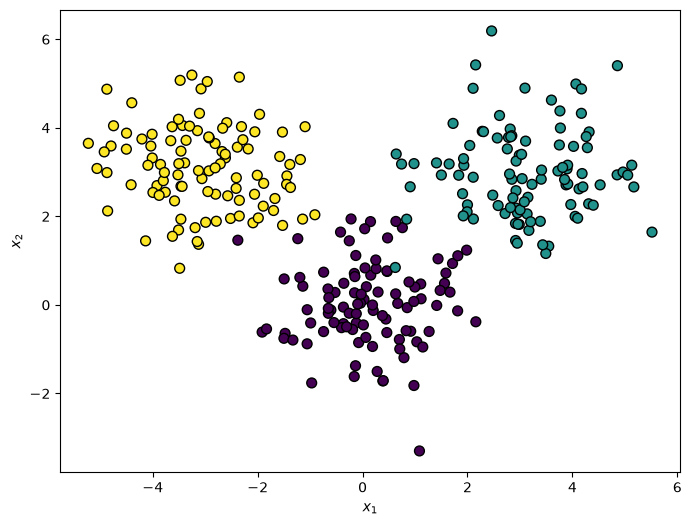

In [20]:
n_samples = 100

centroids = {
    'class_0': np.array([0, 0], dtype=float),
    'class_1': np.array([3, 3], dtype=float),
    'class_2': np.array([-3, 3], dtype=float)
}

data_class_0 = np.random.randn(n_samples, 2) + centroids['class_0']
data_class_1 = np.random.randn(n_samples, 2) + centroids['class_1']
data_class_2 = np.random.randn(n_samples, 2) + centroids['class_2']


data = np.concatenate((data_class_0, data_class_1, data_class_2), axis=0)

my_labels = np.concatenate((np.zeros(n_samples, dtype=np.long),
               np.ones(n_samples, dtype=np.long),
               np.ones(n_samples, dtype=np.long) * 2))

indices=np.random.permutation(data.shape[0])
X=data[indices]
labels=my_labels[indices]
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')

plt.show()

Nuestras clases son categorías, por lo que las vamos a transformar en variables **one-hot**, que son vectores de dimensión del número de clases llenos de ceros, donde solo el elemento de la clase $i$ es 1.
$$(0,1,2)\to y \in \left\{\begin{bmatrix} 1\\ 0\\ 0\end{bmatrix},\begin{bmatrix} 0\\ 1\\ 0\end{bmatrix}, \begin{bmatrix} 0\\0\\ 1\end{bmatrix}\right\}.$$


In [7]:
num_classes=3
y=np.zeros((labels.shape[0],num_classes))

for m in range(labels.shape[0]):
    y[m,labels[m]]=1

y[:4],labels[:4];

En la **regresión softmax**, dado un punto $\boldsymbol{x}$, asignamos la probabilidad $\hat{y}_j$ de que pertenezca a cada clase $j$ utilizando primero una combinación lineal de sus características $x_1, x_2$:

$$
o_j = \sum_{i=1}^n W_{ji}x_i + b_j
$$

y luego aplicamos la función softmax al resultado:

$$
\hat{y}_j = \text{softmax}(\boldsymbol{o})_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}.
$$

Esta operación puede vectorizarse fácilmente considerando un vector $\hat{\boldsymbol{y}} = (\hat{y}_0, \hat{y}_1, \hat{y}_2)$, una matriz $W$ (de tamaño $3 \times 2$) y un vector de sesgo $\boldsymbol{b} = (b_0, b_1, b_2)$:

$$
\hat{\boldsymbol{y}} = \text{softmax}(\boldsymbol{o}) \quad \text{con} \quad \boldsymbol{o} = W\boldsymbol{x} + \boldsymbol{b}.
$$

Como siempre, podemos aplicar esta operación a todo el conjunto de datos reemplazando $\boldsymbol{x}$ por la matriz de datos $X$ y $\hat{\boldsymbol{y}}$ por una matriz de etiquetas predichas $\hat{Y}$ de tamaño $M \times 3$, donde $M$ es el número de muestras:

$$
\hat{Y} = \text{softmax}(O) \quad \text{con} \quad O = XW + \boldsymbol{b}.
$$

Definimos una función para inicializar los parámetros del modelo

In [10]:
def init(input_size, num_classes):
    bias = np.zeros(num_classes)
    weights = np.zeros((input_size, num_classes))
    return weights,bias
weights,bias=init(input_size=X.shape[1], num_classes=y.shape[1])

y para obtener las probabilidades de cada clase para cada punto del conjunto de datos. Para ello, primero debemos escribir una función **softmax** que tome la matriz $O$ y calcule $\hat{Y}$.

In [11]:
def softmax(O):
    O_exp = np.exp(O)
    partition = O_exp.sum(1)
    return O_exp / partition.reshape(-1,1)

O=X@weights+bias
hatY=softmax(O)
np.argmax(hatY,axis=1),np.argmax(O,axis=1);

### Función de pérdida

Como es habitual, necesitamos una **función de pérdida** para realizar el entrenamiento. Como se explicó en clase, la elección más común en este caso es la **entropía cruzada**:

$$
L = -\frac{1}{M}\sum_{m=1}^M \sum_{j=1}^q y^{(m)}_j \log \hat{y}^{m}_j = -\frac{1}{M}\sum_{m=1}^M \sum_{j=1}^q y_j^{(m)} \log \frac{\exp(o_j^{(m)})}{\sum_{k=1}^q \exp(o_k^{(m)})},
$$

donde
$$
o_j^{(m)} = \sum_{i=1}^n W_{ji}x_i^{(m)} + b_j.
$$

### Gradientes

El gradiente de la pérdida con respecto a los pesos $W_{ji}$ es:

$$
\frac{\partial L}{\partial W_{ji}} = \frac{1}{M}\sum_{m=1}^M (\hat{y}_j^{(m)} - y^{(m)}_j) x_i^{(m)},
$$

y el gradiente con respecto a los sesgos $b_j$ es:

$$
\frac{\partial L}{\partial b_j} = \frac{1}{M}\sum_{m=1}^M (\hat{y}_j^{(m)} - y^{(m)}_j).
$$

### Programa de entrenamiento

Incluimos todas las funciones que necesitamos

In [14]:
def init_model(input_size, num_classes):
    return {
        "weights": np.zeros((input_size, num_classes)),
        "bias": np.zeros(num_classes)
    }

def softmax(O):
    O_exp = np.exp(O)
    partition = O_exp.sum(1)
    return O_exp / partition.reshape(-1,1)

def parameters(model):
    return [model["weights"], model["bias"]]

def predict(model, X):
    o = X @ model["weights"] + model["bias"].reshape(1, -1)
    return np.argmax(o, axis=1)

def probabilities(model, X):
    o = X @ model["weights"] + model["bias"].reshape(1, -1)
    return softmax(o)

def cross_entropy_loss(model, X, labels):
    p = probabilities(model, X)
    return -np.sum(labels * np.log(p + 1e-8)) / X.shape[0]

def errors(model, X, labels):
    class_pred = predict(model, X)
    class_original = np.argmax(labels, axis=1)
    return np.mean(class_pred != class_original)

def train(model, X, labels, epochs, η=0.01):
    data = np.zeros((epochs, 2))

    for ep in range(epochs):
        p = probabilities(model, X)
        
        partial = p - labels
        
        grad_w = (partial.T @ X).T

        model["weights"] -= η * grad_w / X.shape[0]
        model["bias"] -= η * np.sum(partial, axis=0) / X.shape[0]

        loss = cross_entropy_loss(model, X, labels)
        err = errors(model, X, labels)

        #print(f"Epoch {ep:5d} | Train loss={loss:.3f} | # errores={err:.3f}")
        
        data[ep] = np.array([loss, err])

    return data

Realiza un entrenamiento con el conjunto de datos artificial creado anteriormente.

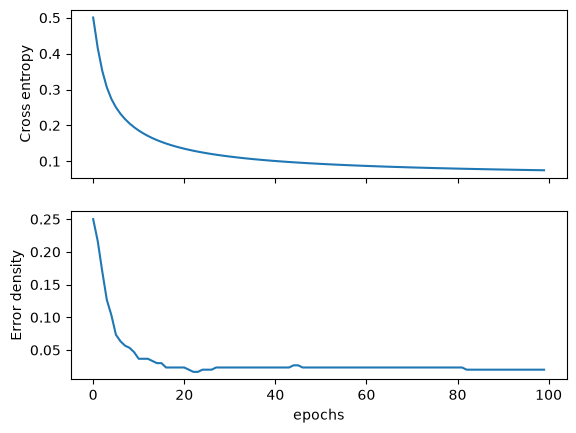

In [16]:
input_size=X.shape[1]
num_clases=3

model = init_model(input_size,num_clases)
history = train(model, X, y, epochs=100, η=1)
preds = predict(model, X)

fig, ax = plt.subplots(2,sharex=True)
ax[0].plot(history[:,0])
ax[1].plot(history[:,1])
ax[0].set_ylabel("Cross entropy")
ax[1].set_ylabel("Error density")
plt.xlabel("epochs")
plt.show()

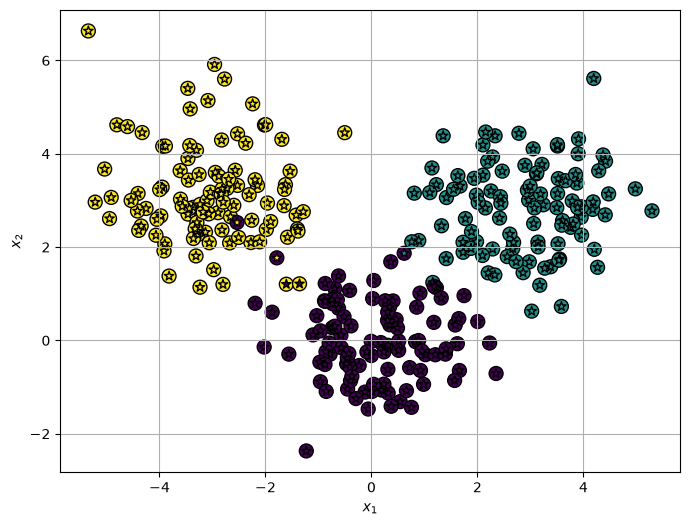

In [17]:
y_pred= predict(model, X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y,axis=1), cmap='viridis', marker='o', edgecolor='k', s=100)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', marker='*', edgecolor='k', s=50)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)
plt.show()

Podemos visualizar fácilmente las **líneas de decisión** que utiliza el algoritmo para separar cada clase, creando una **malla de puntos** $(x, y)$.

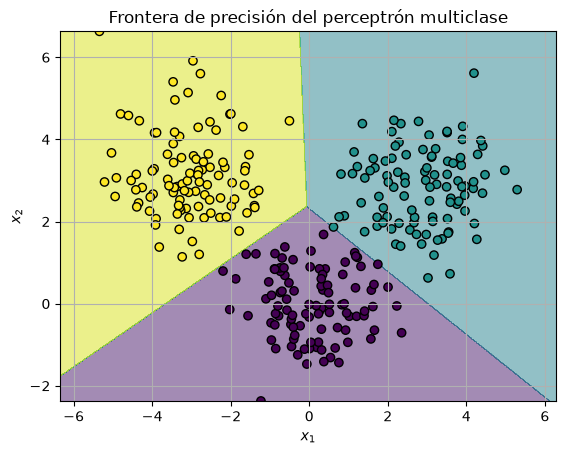

In [18]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = predict(model,grid)
Z = preds.reshape(xx.shape)

x = np.linspace(-5, 5, 100)
w, bias =parameters(model)  

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', edgecolors='k')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)

plt.ylim(X[:,1].min(),X[:,1].max())
plt.title('Frontera de precisión del perceptrón multiclase')
plt.show()

Es posible demostrar  que las fronteras de decisión coinciden con las líneas donde las probabilidades de dos clases son iguales:
Para que las probabilidades de dos clases \(j\) y \(k\) sean iguales en la regresión softmax, se debe cumplir que sus **scores** \(o_j\) y \(o_k\) sean iguales:
$$
o_j = o_k
$$
Sustituyendo la expresión de \(o_j\) y \(o_k\):
$$
w_{j1}x_1 + w_{j2}x_2 + b_j = w_{k1}x_1 + w_{k2}x_2 + b_k
$$
Despejando \(x_2\):
$$
w_{j2}x_2 - w_{k2}x_2 = w_{k1}x_1 - w_{j1}x_1 + b_k - b_j
$$
$$
x_2(w_{j2} - w_{k2}) = x_1(w_{k1} - w_{j1}) + (b_k - b_j)
$$
Finalmente, obtenemos la ecuación de una **línea recta**:
$$
x_2 = \frac{w_{j1} - w_{k1}}{w_{j2} - w_{k2}} x_1 + \frac{b_j - b_k}{w_{j2} - w_{k2}}
$$
Esto demuestra que la clasificación multiclase con softmax divide el espacio en regiones lineales.

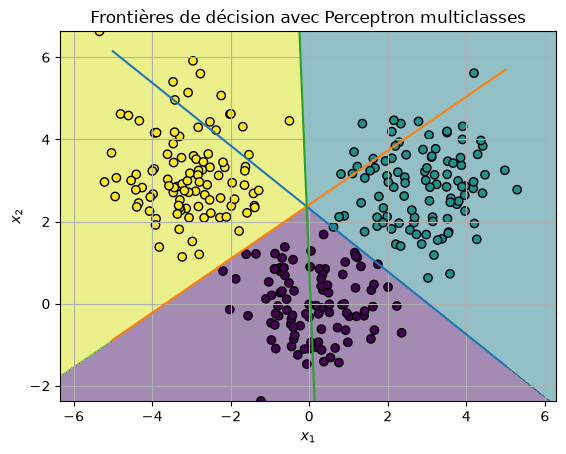

In [19]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = predict(model,grid)

Z = preds.reshape(xx.shape)

x = np.linspace(-5, 5, 100)
w, bias = parameters(model) 

my=(w[0,0]-w[0,1])/(w[1,1]-w[1,0])*x+(bias[0]-bias[1])/(w[1,1]-w[1,0])
plt.plot(x, my, label=f'Classes 0-1 Boundary')
my=(w[0,0]-w[0,2])/(w[1,2]-w[1,0])*x+(bias[0]-bias[2])/(w[1,2]-w[1,0])
plt.plot(x, my, label=f'Classes 0-2 Boundary')
my=(w[0,1]-w[0,2])/(w[1,2]-w[1,1])*x+(bias[1]-bias[2])/(w[1,2]-w[1,1])
plt.plot(x, my, label=f'Classes 1-2 Boundary')

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', edgecolors='k')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)

plt.ylim(X[:,1].min(),X[:,1].max())
plt.title('Frontières de décision avec Perceptron multiclasses')
plt.show()